# Paper 1 — Figure 2: Colon Epithelium is the Sole Exception to Myeloid Dominance


In [1]:
import pandas as pd, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, glob
from scipy.stats import hypergeom, mannwhitneyu
%matplotlib inline
plt.rcParams.update({'font.family': 'Arial', 'font.size': 11, 'pdf.fonttype': 42})
BASE = '../analysis/26_gsmap'
os.makedirs(f'{BASE}/figures/paper1', exist_ok=True)
print('Setup complete.')


Setup complete.


In [2]:
# Cell 3: Load age-resolved cauchy data and classify cell types
df = pd.read_csv(f'{BASE}/results/age_all_cauchy_AD.csv.gz')
print(f'Loaded {len(df)} rows, {df["organ"].nunique()} organs')

# Fix organ names: strip trailing _## from PanSci-style names
df['organ_clean'] = df['organ'].str.replace(r'_\d+$', '', regex=True)

# Classify annotations as Myeloid vs Non-myeloid
myeloid_keywords = ['myeloid', 'macrophage', 'microgl', 'monocyte', 'kupffer', 'dendri']
pattern = '|'.join(myeloid_keywords)
df['is_myeloid'] = df['annotation'].str.lower().str.contains(pattern, regex=True)
print(f'Myeloid annotations: {df[df["is_myeloid"]]["annotation"].nunique()}')
print(f'Non-myeloid annotations: {df[~df["is_myeloid"]]["annotation"].nunique()}')

# For each organ, compute best (min) myeloid p and best non-myeloid p across all ages
organ_myeloid = df[df['is_myeloid']].groupby('organ_clean')['p_cauchy'].min().rename('myeloid_p')
organ_nonmyeloid = df[~df['is_myeloid']].groupby('organ_clean')['p_cauchy'].min().rename('nonmyeloid_p')

organ_summary = pd.concat([organ_myeloid, organ_nonmyeloid], axis=1).dropna()
organ_summary['myeloid_logp'] = -np.log10(organ_summary['myeloid_p'].clip(lower=1e-300))
organ_summary['nonmyeloid_logp'] = -np.log10(organ_summary['nonmyeloid_p'].clip(lower=1e-300))
organ_summary = organ_summary.sort_values('myeloid_logp', ascending=True)

# Identify the best non-myeloid annotation for each organ
best_nonmyeloid = df[~df['is_myeloid']].loc[df[~df['is_myeloid']].groupby('organ_clean')['p_cauchy'].idxmin()]
best_nonmyeloid_dict = dict(zip(best_nonmyeloid['organ_clean'], best_nonmyeloid['annotation']))

print(f'\nOrgans in summary: {len(organ_summary)}')
print(organ_summary[['myeloid_logp', 'nonmyeloid_logp']].round(2))

# Check which organs have non-myeloid > myeloid
exceptions = organ_summary[organ_summary['nonmyeloid_logp'] > organ_summary['myeloid_logp']]
print(f'\nOrgans where non-myeloid beats myeloid: {list(exceptions.index)}')
for org in exceptions.index:
    print(f'  {org}: best non-myeloid = {best_nonmyeloid_dict.get(org, "?")}')


Loaded 1402 rows, 15 organs
Myeloid annotations: 24
Non-myeloid annotations: 231

Organs in summary: 12
             myeloid_logp  nonmyeloid_logp
organ_clean                               
Colon                4.87             6.16
Ileum                5.38             6.75
Stomach              5.73             6.14
Heart                6.26             8.51
Spleen               6.81             9.33
Kidney               7.69             7.02
BAT                  8.05             5.31
Brain                8.86             4.11
Bone_Marrow          9.29             9.51
Liver                9.31             5.29
Muscle               9.42             6.54
Lung                 9.91             5.88

Organs where non-myeloid beats myeloid: ['Colon', 'Ileum', 'Stomach', 'Heart', 'Spleen', 'Bone_Marrow']
  Colon: best non-myeloid = cluster_12
  Ileum: best non-myeloid = 12
  Stomach: best non-myeloid = 10
  Heart: best non-myeloid = leukocyte
  Spleen: best non-myeloid = 5
  Bone_Marrow: be

Panel A saved.


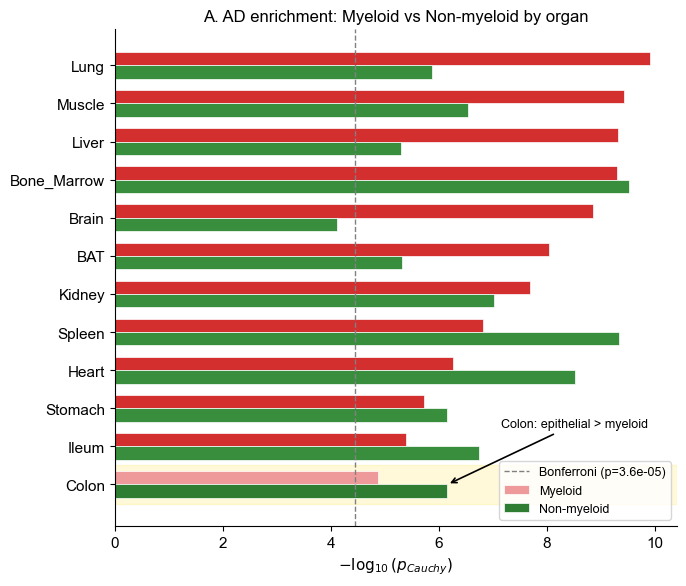

In [3]:
# Cell 4: Panel A — All organs myeloid vs non-myeloid (grouped bar chart)
fig, ax = plt.subplots(figsize=(7, 6))

organs = organ_summary.index.tolist()
y_pos = np.arange(len(organs))
bar_height = 0.35

# Bonferroni threshold
n_tests = len(df)
bonf_thresh = -np.log10(0.05 / n_tests)

# Colors: highlight Colon differently
myeloid_colors = ['#D32F2F' if org != 'Colon' else '#EF9A9A' for org in organs]
nonmyeloid_colors = ['#388E3C' if org != 'Colon' else '#2E7D32' for org in organs]

bars1 = ax.barh(y_pos + bar_height/2, organ_summary['myeloid_logp'].values,
                bar_height, color=myeloid_colors, label='Myeloid', edgecolor='white', linewidth=0.5)
bars2 = ax.barh(y_pos - bar_height/2, organ_summary['nonmyeloid_logp'].values,
                bar_height, color=nonmyeloid_colors, label='Non-myeloid', edgecolor='white', linewidth=0.5)

# Highlight Colon row
colon_idx = organs.index('Colon') if 'Colon' in organs else None
if colon_idx is not None:
    ax.axhspan(colon_idx - 0.5, colon_idx + 0.5, alpha=0.15, color='gold', zorder=0)
    ax.annotate('Colon: epithelial > myeloid', xy=(organ_summary.loc['Colon', 'nonmyeloid_logp'], colon_idx),
                xytext=(organ_summary.loc['Colon', 'nonmyeloid_logp'] + 1, colon_idx + 1.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                fontsize=9, fontweight='bold')

ax.axvline(bonf_thresh, color='gray', linestyle='--', linewidth=1, label=f'Bonferroni (p={0.05/n_tests:.1e})')
ax.set_yticks(y_pos)
ax.set_yticklabels(organs)
ax.set_xlabel('$-\\log_{10}(p_{Cauchy})$')
ax.set_title('A. AD enrichment: Myeloid vs Non-myeloid by organ', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig2A_organ_myeloid_bars.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{BASE}/figures/paper1/Fig2A_organ_myeloid_bars.pdf', bbox_inches='tight')
print('Panel A saved.')
plt.show()


Brain: 8875 cells, 0.8% myeloid, 0.0% epithelial, -logp=8.9


Liver: 9981 cells, 6.1% myeloid, 80.1% epithelial, -logp=9.3


Lung: 9996 cells, 18.1% myeloid, 27.9% epithelial, -logp=9.9
Colon: 10000 cells, 3.7% myeloid, 61.1% epithelial, -logp=4.9


Ileum: 9994 cells, 5.4% myeloid, 42.2% epithelial, -logp=5.4


Stomach: 9440 cells, 3.8% myeloid, 37.1% epithelial, -logp=5.7


Spleen: 9569 cells, 0.0% myeloid, 0.0% epithelial, -logp=6.8


Bone_Marrow: 6712 cells, 17.5% myeloid, 0.0% epithelial, -logp=9.3


Panel B saved.


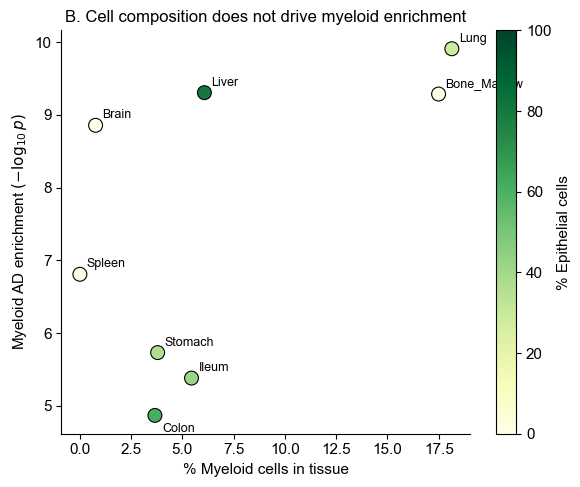

In [4]:
# Cell 5: Panel B — Cell composition control
# For key organs, load one cmap h5ad and compute %myeloid and %epithelial
import scanpy as sc

key_organs = ['Brain', 'Liver', 'Lung', 'Colon', 'Ileum', 'Stomach', 'Spleen', 'Bone_Marrow']
myeloid_keywords = ['myeloid', 'macrophage', 'microgl', 'monocyte', 'kupffer', 'dendri']
epithelial_keywords = ['epithelial', 'hepatocyte', 'enterocyte', 'goblet', 'pneumocyte',
                        'alveolar epithelial', 'colonocyte', 'chief cell', 'parietal']
myeloid_pat = '|'.join(myeloid_keywords)
epithelial_pat = '|'.join(epithelial_keywords)

comp_data = []
for organ in key_organs:
    files = sorted(glob.glob(f'{BASE}/models/cmap_output/{organ}/*.h5ad'))
    if not files:
        print(f'{organ}: no cmap files')
        continue
    # Use first file
    adata = sc.read_h5ad(files[0], backed='r')
    annots = adata.obs['annotation'].values.astype(str)
    n_total = len(annots)
    annot_lower = pd.Series(annots).str.lower()
    n_myeloid = annot_lower.str.contains(myeloid_pat, regex=True).sum()
    n_epithelial = annot_lower.str.contains(epithelial_pat, regex=True).sum()
    pct_myeloid = 100.0 * n_myeloid / n_total
    pct_epithelial = 100.0 * n_epithelial / n_total
    # Get myeloid enrichment for this organ
    mlogp = organ_summary.loc[organ, 'myeloid_logp'] if organ in organ_summary.index else np.nan
    comp_data.append({'organ': organ, 'pct_myeloid': pct_myeloid, 'pct_epithelial': pct_epithelial,
                      'myeloid_logp': mlogp, 'n_total': n_total})
    print(f'{organ}: {n_total} cells, {pct_myeloid:.1f}% myeloid, {pct_epithelial:.1f}% epithelial, -logp={mlogp:.1f}')

comp_df = pd.DataFrame(comp_data)

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(comp_df['pct_myeloid'], comp_df['myeloid_logp'],
                     s=100, c=comp_df['pct_epithelial'], cmap='YlGn', edgecolors='black', linewidth=0.8,
                     vmin=0, vmax=100, zorder=5)
cbar = plt.colorbar(scatter, ax=ax, label='% Epithelial cells')

# Label each point
for _, row in comp_df.iterrows():
    offset = (5, 5)
    if row['organ'] == 'Colon':
        offset = (5, -12)
    ax.annotate(row['organ'], (row['pct_myeloid'], row['myeloid_logp']),
                textcoords='offset points', xytext=offset, fontsize=9,
                fontweight='bold' if row['organ'] in ['Liver', 'Colon'] else 'normal')

ax.set_xlabel('% Myeloid cells in tissue')
ax.set_ylabel('Myeloid AD enrichment $(-\\log_{10}p)$')
ax.set_title('B. Cell composition does not drive myeloid enrichment', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig2B_composition_control.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{BASE}/figures/paper1/Fig2B_composition_control.pdf', bbox_inches='tight')
print('Panel B saved.')
plt.show()


Loaded diagnostic info: 15388 genes
Found 49/55 AD genes in diagnostic info


Panel C saved.


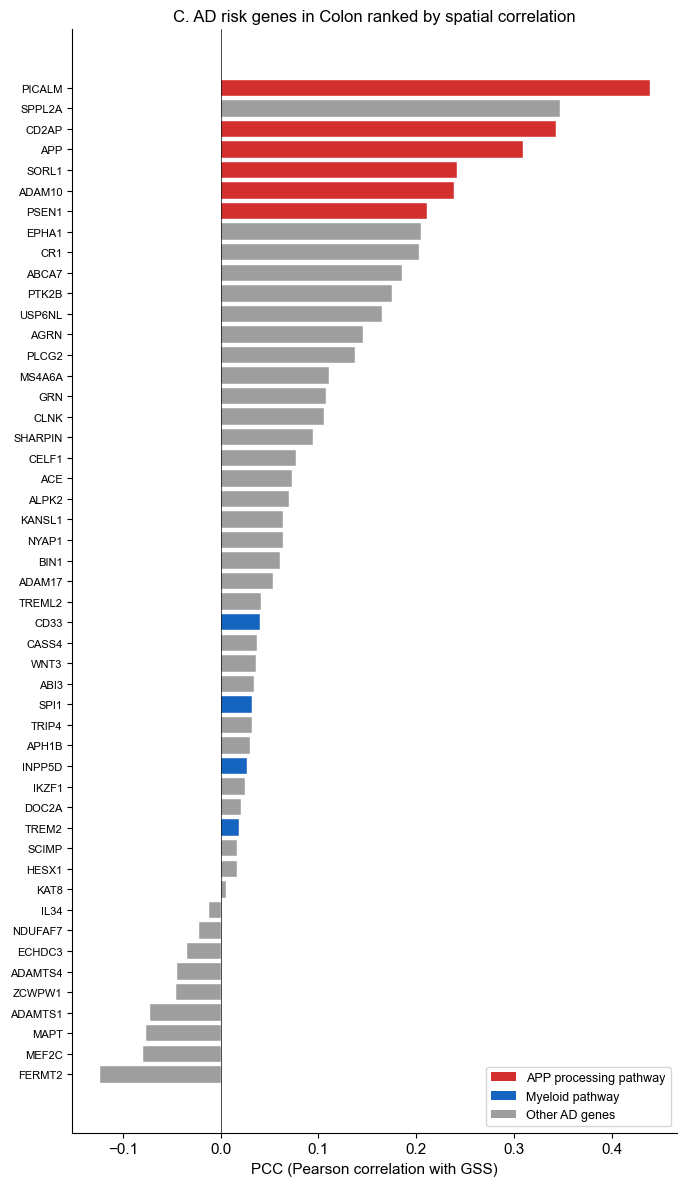

In [5]:
# Cell 6: Panel C — AD risk genes in Colon ranked by PCC
diag = pd.read_csv(f'{BASE}/models/gsmap_output/Colon_CTRL1/report/AD/Colon_CTRL1_AD_Gene_Diagnostic_Info.csv')
print(f'Loaded diagnostic info: {len(diag)} genes')

# 55 established AD risk genes (human nomenclature, matching diagnostic info)
AD_GENES = [
    'APP', 'TREM2', 'CD33', 'SPI1', 'PICALM', 'SORL1', 'ADAM10', 'PSEN1',
    'BIN1', 'CLU', 'ABCA7', 'CR1', 'CD2AP', 'INPP5D', 'APOE', 'EPHA1',
    'MS4A6A', 'MS4A4E', 'PTK2B', 'CASS4', 'FERMT2', 'ZCWPW1', 'CELF1',
    'NME8', 'HLADRB5', 'MEF2C', 'KANSL1', 'MAPT', 'ACE', 'TRIP4',
    'ECHDC3', 'NDUFAF7', 'SCIMP', 'PLCG2', 'ABI3', 'GRN', 'PILRA',
    'TREML2', 'SHARPIN', 'KAT8', 'USP6NL', 'SPPL2A', 'NYAP1', 'APH1B',
    'ADAM17', 'IL34', 'ADAMTS4', 'HESX1', 'CLNK', 'ALPK2', 'AGRN',
    'IKZF1', 'DOC2A', 'WNT3', 'ADAMTS1'
]

# APP pathway genes
APP_PATHWAY = ['APP', 'PICALM', 'CD2AP', 'SORL1', 'ADAM10', 'PSEN1']
# Myeloid genes
MYELOID_GENES = ['TREM2', 'CD33', 'SPI1', 'INPP5D']

# Filter diagnostic info to AD genes
ad_diag = diag[diag['Gene'].isin(AD_GENES)].copy()
ad_diag = ad_diag.drop_duplicates(subset='Gene').sort_values('PCC', ascending=True)
print(f'Found {len(ad_diag)}/{len(AD_GENES)} AD genes in diagnostic info')

# Assign color categories
def gene_color(g):
    if g in APP_PATHWAY:
        return '#D32F2F'  # red
    elif g in MYELOID_GENES:
        return '#1565C0'  # blue
    else:
        return '#9E9E9E'  # gray

colors = [gene_color(g) for g in ad_diag['Gene']]

fig, ax = plt.subplots(figsize=(7, 12))
y_pos = np.arange(len(ad_diag))
bars = ax.barh(y_pos, ad_diag['PCC'].values, color=colors, edgecolor='white', linewidth=0.3)
ax.set_yticks(y_pos)
ax.set_yticklabels(ad_diag['Gene'].values, fontsize=8)
ax.set_xlabel('PCC (Pearson correlation with GSS)')
ax.set_title('C. AD risk genes in Colon ranked by spatial correlation', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#D32F2F', label='APP processing pathway'),
                   Patch(facecolor='#1565C0', label='Myeloid pathway'),
                   Patch(facecolor='#9E9E9E', label='Other AD genes')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig2C_ad_genes_pcc.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{BASE}/figures/paper1/Fig2C_ad_genes_pcc.pdf', bbox_inches='tight')
print('Panel C saved.')
plt.show()


APP pathway genes found: ['APP', 'PICALM', 'CD2AP', 'SORL1', 'ADAM10', 'PSEN1']
APP pathway mean PCC: 0.2970


Permutation p-value: 0.000000
Z-score: 4.68


Panel D saved.


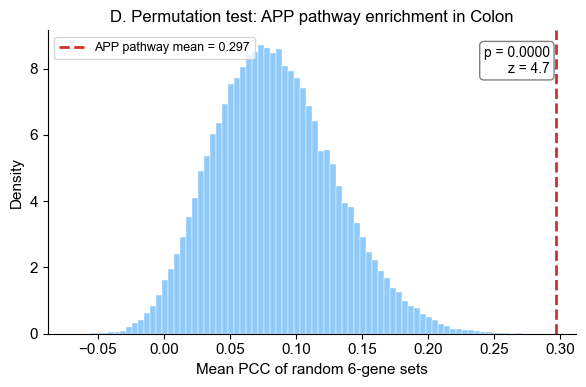

In [6]:
# Cell 7: Panel D — Permutation test (100K iterations)
# Reload ad_diag if needed
diag = pd.read_csv(f'{BASE}/models/gsmap_output/Colon_CTRL1/report/AD/Colon_CTRL1_AD_Gene_Diagnostic_Info.csv')
AD_GENES = [
    'APP', 'TREM2', 'CD33', 'SPI1', 'PICALM', 'SORL1', 'ADAM10', 'PSEN1',
    'BIN1', 'CLU', 'ABCA7', 'CR1', 'CD2AP', 'INPP5D', 'APOE', 'EPHA1',
    'MS4A6A', 'MS4A4E', 'PTK2B', 'CASS4', 'FERMT2', 'ZCWPW1', 'CELF1',
    'NME8', 'HLADRB5', 'MEF2C', 'KANSL1', 'MAPT', 'ACE', 'TRIP4',
    'ECHDC3', 'NDUFAF7', 'SCIMP', 'PLCG2', 'ABI3', 'GRN', 'PILRA',
    'TREML2', 'SHARPIN', 'KAT8', 'USP6NL', 'SPPL2A', 'NYAP1', 'APH1B',
    'ADAM17', 'IL34', 'ADAMTS4', 'HESX1', 'CLNK', 'ALPK2', 'AGRN',
    'IKZF1', 'DOC2A', 'WNT3', 'ADAMTS1'
]
APP_PATHWAY = ['APP', 'PICALM', 'CD2AP', 'SORL1', 'ADAM10', 'PSEN1']

ad_diag = diag[diag['Gene'].isin(AD_GENES)].drop_duplicates(subset='Gene')
ad_pcc = ad_diag.set_index('Gene')['PCC']

# APP pathway mean PCC
app_genes_found = [g for g in APP_PATHWAY if g in ad_pcc.index]
app_mean_pcc = ad_pcc.loc[app_genes_found].mean()
print(f'APP pathway genes found: {app_genes_found}')
print(f'APP pathway mean PCC: {app_mean_pcc:.4f}')

# Permutation: sample len(app_genes_found) random AD genes, compute mean PCC
n_perm = 100000
n_app = len(app_genes_found)
all_pcc_vals = ad_pcc.values
rng = np.random.default_rng(42)
perm_means = np.array([
    rng.choice(all_pcc_vals, size=n_app, replace=False).mean()
    for _ in range(n_perm)
])

perm_p = (perm_means >= app_mean_pcc).sum() / n_perm
perm_z = (app_mean_pcc - perm_means.mean()) / perm_means.std()
print(f'Permutation p-value: {perm_p:.6f}')
print(f'Z-score: {perm_z:.2f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(perm_means, bins=80, color='#90CAF9', edgecolor='white', linewidth=0.3, density=True)
ax.axvline(app_mean_pcc, color='#D32F2F', linewidth=2, linestyle='--',
           label=f'APP pathway mean = {app_mean_pcc:.3f}')
ax.set_xlabel('Mean PCC of random 6-gene sets')
ax.set_ylabel('Density')
ax.set_title('D. Permutation test: APP pathway enrichment in Colon', fontsize=12, fontweight='bold')
ax.text(0.95, 0.95, f'p = {perm_p:.4f}\nz = {perm_z:.1f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
ax.legend(loc='upper left', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig2D_permutation_test.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{BASE}/figures/paper1/Fig2D_permutation_test.pdf', bbox_inches='tight')
print('Panel D saved.')
plt.show()


Colon-expressed AD genes (PCC > 0.1): 17
  Genes: ['APP', 'PICALM', 'SORL1', 'ADAM10', 'PSEN1', 'ABCA7', 'CR1', 'CD2AP', 'EPHA1', 'MS4A6A', 'PTK2B', 'PLCG2', 'GRN', 'USP6NL', 'SPPL2A', 'CLNK', 'AGRN']

Hypergeometric test:
  N (total AD genes) = 49
  K (APP pathway) = 6
  n (colon-expressed) = 17
  k (overlap) = 6
  Expected overlap = 2.08
  p-value = 8.8502e-04
Panel E saved.


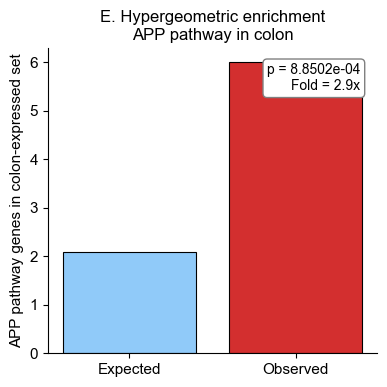

In [7]:
# Cell 8: Panel E — Hypergeometric test for APP pathway enrichment in colon-expressed AD genes
import scanpy as sc

# Load spatial data to determine colon-expressed genes
adata = sc.read_h5ad(f'{BASE}/data/st/per_organ/Colon_CTRL1.h5ad', backed='r')
var_names_upper = {v.upper(): v for v in adata.var_names}

AD_GENES = [
    'APP', 'TREM2', 'CD33', 'SPI1', 'PICALM', 'SORL1', 'ADAM10', 'PSEN1',
    'BIN1', 'CLU', 'ABCA7', 'CR1', 'CD2AP', 'INPP5D', 'APOE', 'EPHA1',
    'MS4A6A', 'MS4A4E', 'PTK2B', 'CASS4', 'FERMT2', 'ZCWPW1', 'CELF1',
    'NME8', 'HLADRB5', 'MEF2C', 'KANSL1', 'MAPT', 'ACE', 'TRIP4',
    'ECHDC3', 'NDUFAF7', 'SCIMP', 'PLCG2', 'ABI3', 'GRN', 'PILRA',
    'TREML2', 'SHARPIN', 'KAT8', 'USP6NL', 'SPPL2A', 'NYAP1', 'APH1B',
    'ADAM17', 'IL34', 'ADAMTS4', 'HESX1', 'CLNK', 'ALPK2', 'AGRN',
    'IKZF1', 'DOC2A', 'WNT3', 'ADAMTS1'
]
APP_PATHWAY = ['APP', 'PICALM', 'CD2AP', 'SORL1', 'ADAM10', 'PSEN1']

# Determine which AD genes are expressed in colon spatial data
# A gene is "expressed" if it exists in the var_names
# Additionally, load diagnostic info and use PCC > 0.1 as meaningful expression threshold
diag = pd.read_csv(f'{BASE}/models/gsmap_output/Colon_CTRL1/report/AD/Colon_CTRL1_AD_Gene_Diagnostic_Info.csv')
ad_diag = diag[diag['Gene'].isin(AD_GENES)].drop_duplicates(subset='Gene')
ad_pcc = ad_diag.set_index('Gene')['PCC']

# "Colon-expressed" = present in spatial data AND PCC > 0.1 (meaningful spatial correlation)
colon_expressed = [g for g in AD_GENES if g in ad_pcc.index and ad_pcc[g] > 0.1]
colon_not_expressed = [g for g in AD_GENES if g not in colon_expressed]

print(f'Colon-expressed AD genes (PCC > 0.1): {len(colon_expressed)}')
print(f'  Genes: {colon_expressed}')

# Hypergeometric test
N = len([g for g in AD_GENES if g in ad_pcc.index])  # total AD genes with data
K = len([g for g in APP_PATHWAY if g in ad_pcc.index])  # APP pathway genes with data
n = len(colon_expressed)  # colon-expressed AD genes
k = len([g for g in APP_PATHWAY if g in colon_expressed])  # overlap

# P(X >= k) under hypergeometric
hyper_p = hypergeom.sf(k - 1, N, K, n)
expected = n * K / N

print(f'\nHypergeometric test:')
print(f'  N (total AD genes) = {N}')
print(f'  K (APP pathway) = {K}')
print(f'  n (colon-expressed) = {n}')
print(f'  k (overlap) = {k}')
print(f'  Expected overlap = {expected:.2f}')
print(f'  p-value = {hyper_p:.4e}')

# Bar chart: observed vs expected
fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(['Expected', 'Observed'], [expected, k],
              color=['#90CAF9', '#D32F2F'], edgecolor='black', linewidth=0.8)
ax.set_ylabel('APP pathway genes in colon-expressed set')
ax.set_title('E. Hypergeometric enrichment\nAPP pathway in colon', fontsize=12, fontweight='bold')
ax.text(0.95, 0.95, f'p = {hyper_p:.4e}\nFold = {k/expected:.1f}x',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig2E_hypergeometric.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{BASE}/figures/paper1/Fig2E_hypergeometric.pdf', bbox_inches='tight')
print('Panel E saved.')
plt.show()


Loaded GO enrichment: 283 terms


Panel F saved.


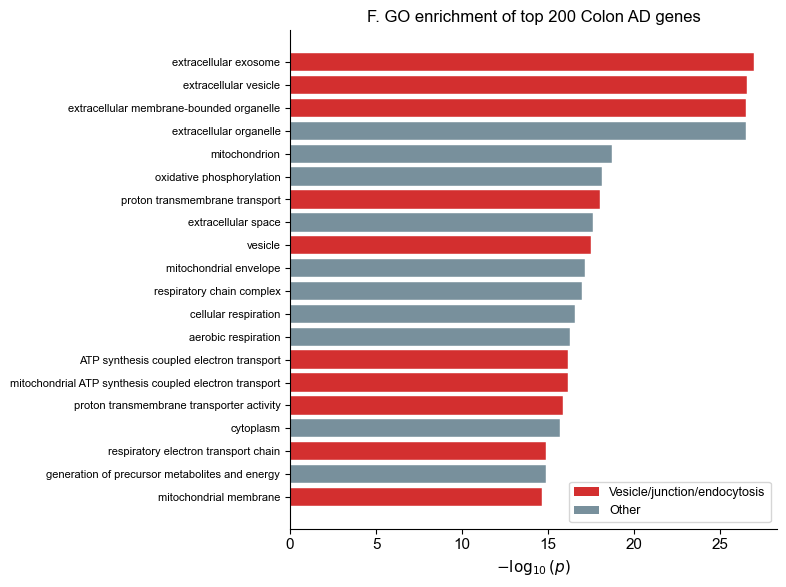

In [8]:
# Cell 9: Panel F — GO enrichment
go_path = f'{BASE}/results/GO_enrichment_colon_AD_top200.csv'

if os.path.exists(go_path):
    go_df = pd.read_csv(go_path)
    print(f'Loaded GO enrichment: {len(go_df)} terms')
else:
    # Run gprofiler if file doesn't exist
    from gprofiler import GProfiler
    diag = pd.read_csv(f'{BASE}/models/gsmap_output/Colon_CTRL1/report/AD/Colon_CTRL1_AD_Gene_Diagnostic_Info.csv')
    top200 = diag.sort_values('PCC', ascending=False).head(200)['Gene'].tolist()
    gp = GProfiler(return_dataframe=True)
    go_df = gp.profile(organism='mmusculus', query=top200)
    go_df.to_csv(go_path, index=False)
    print(f'Computed and saved GO enrichment: {len(go_df)} terms')

# Filter to GO:BP and GO:CC
go_plot = go_df[go_df['source'].isin(['GO:BP', 'GO:CC', 'GO:MF'])].copy()
go_plot = go_plot.sort_values('p_value').head(20)
go_plot['neg_logp'] = -np.log10(go_plot['p_value'].clip(lower=1e-300))

# Highlight vesicle/junction/endocytosis terms
highlight_kw = ['vesicle', 'junction', 'endocyt', 'exosome', 'membrane', 'transport', 'secretion']
highlight_pat = '|'.join(highlight_kw)

def go_color(name):
    if pd.Series([name.lower()]).str.contains(highlight_pat, regex=True).iloc[0]:
        return '#D32F2F'
    return '#78909C'

colors = [go_color(n) for n in go_plot['name']]

fig, ax = plt.subplots(figsize=(8, 6))
go_plot_sorted = go_plot.sort_values('neg_logp', ascending=True)
colors_sorted = [go_color(n) for n in go_plot_sorted['name']]
ax.barh(range(len(go_plot_sorted)), go_plot_sorted['neg_logp'].values,
        color=colors_sorted, edgecolor='white', linewidth=0.3)
ax.set_yticks(range(len(go_plot_sorted)))
ax.set_yticklabels(go_plot_sorted['name'].values, fontsize=8)
ax.set_xlabel('$-\\log_{10}(p)$')
ax.set_title('F. GO enrichment of top 200 Colon AD genes', fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#D32F2F', label='Vesicle/junction/endocytosis'),
                   Patch(facecolor='#78909C', label='Other')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig2F_go_enrichment.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{BASE}/figures/paper1/Fig2F_go_enrichment.pdf', bbox_inches='tight')
print('Panel F saved.')
plt.show()


Colon-expressed (PCC > 0.1): n=17
Not colon-expressed (PCC <= 0.1): n=32
Mann-Whitney U test: U=544, p=5.90e-09


/tmp/ipykernel_13592/605834701.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=[f'Expressed\n(n={len(pcc_expressed)})',


Panel G saved.


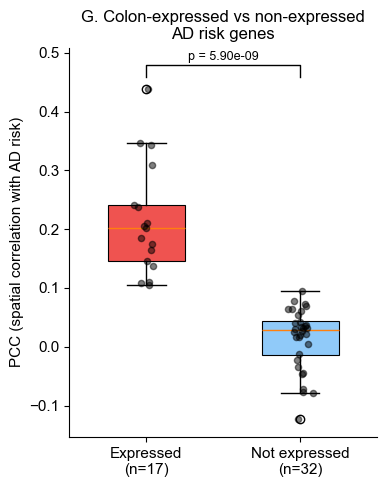

In [9]:
# Cell 10: Panel G — Colon-expressed AD genes vs non-expressed (box plot)
diag = pd.read_csv(f'{BASE}/models/gsmap_output/Colon_CTRL1/report/AD/Colon_CTRL1_AD_Gene_Diagnostic_Info.csv')
AD_GENES = [
    'APP', 'TREM2', 'CD33', 'SPI1', 'PICALM', 'SORL1', 'ADAM10', 'PSEN1',
    'BIN1', 'CLU', 'ABCA7', 'CR1', 'CD2AP', 'INPP5D', 'APOE', 'EPHA1',
    'MS4A6A', 'MS4A4E', 'PTK2B', 'CASS4', 'FERMT2', 'ZCWPW1', 'CELF1',
    'NME8', 'HLADRB5', 'MEF2C', 'KANSL1', 'MAPT', 'ACE', 'TRIP4',
    'ECHDC3', 'NDUFAF7', 'SCIMP', 'PLCG2', 'ABI3', 'GRN', 'PILRA',
    'TREML2', 'SHARPIN', 'KAT8', 'USP6NL', 'SPPL2A', 'NYAP1', 'APH1B',
    'ADAM17', 'IL34', 'ADAMTS4', 'HESX1', 'CLNK', 'ALPK2', 'AGRN',
    'IKZF1', 'DOC2A', 'WNT3', 'ADAMTS1'
]

ad_diag = diag[diag['Gene'].isin(AD_GENES)].drop_duplicates(subset='Gene')
ad_pcc = ad_diag.set_index('Gene')['PCC']

# Split into colon-expressed (PCC > 0.1) vs not
expressed_genes = [g for g in ad_pcc.index if ad_pcc[g] > 0.1]
not_expressed_genes = [g for g in ad_pcc.index if ad_pcc[g] <= 0.1]

pcc_expressed = ad_pcc.loc[expressed_genes]
pcc_not_expressed = ad_pcc.loc[not_expressed_genes]

print(f'Colon-expressed (PCC > 0.1): n={len(pcc_expressed)}')
print(f'Not colon-expressed (PCC <= 0.1): n={len(pcc_not_expressed)}')

stat, mw_p = mannwhitneyu(pcc_expressed, pcc_not_expressed, alternative='greater')
print(f'Mann-Whitney U test: U={stat:.0f}, p={mw_p:.2e}')

fig, ax = plt.subplots(figsize=(4, 5))
data_to_plot = [pcc_expressed.values, pcc_not_expressed.values]
bp = ax.boxplot(data_to_plot, labels=[f'Expressed\n(n={len(pcc_expressed)})',
                                       f'Not expressed\n(n={len(pcc_not_expressed)})'],
                patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#EF5350')
bp['boxes'][1].set_facecolor('#90CAF9')
for box in bp['boxes']:
    box.set_edgecolor('black')
    box.set_linewidth(0.8)

# Add individual points
for i, vals in enumerate(data_to_plot):
    x = np.random.default_rng(42).normal(i + 1, 0.04, size=len(vals))
    ax.scatter(x, vals, alpha=0.5, s=20, color='black', zorder=5)

# Significance bracket
max_y = max(pcc_expressed.max(), pcc_not_expressed.max())
ax.plot([1, 1, 2, 2], [max_y + 0.02, max_y + 0.04, max_y + 0.04, max_y + 0.02],
        color='black', linewidth=1)
ax.text(1.5, max_y + 0.05, f'p = {mw_p:.2e}', ha='center', fontsize=9)

ax.set_ylabel('PCC (spatial correlation with AD risk)')
ax.set_title('G. Colon-expressed vs non-expressed\nAD risk genes', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(f'{BASE}/figures/paper1/Fig2G_expressed_vs_not.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{BASE}/figures/paper1/Fig2G_expressed_vs_not.pdf', bbox_inches='tight')
print('Panel G saved.')
plt.show()


Composite figure saved to figures/paper1/Fig2_colon_exception.png and .pdf


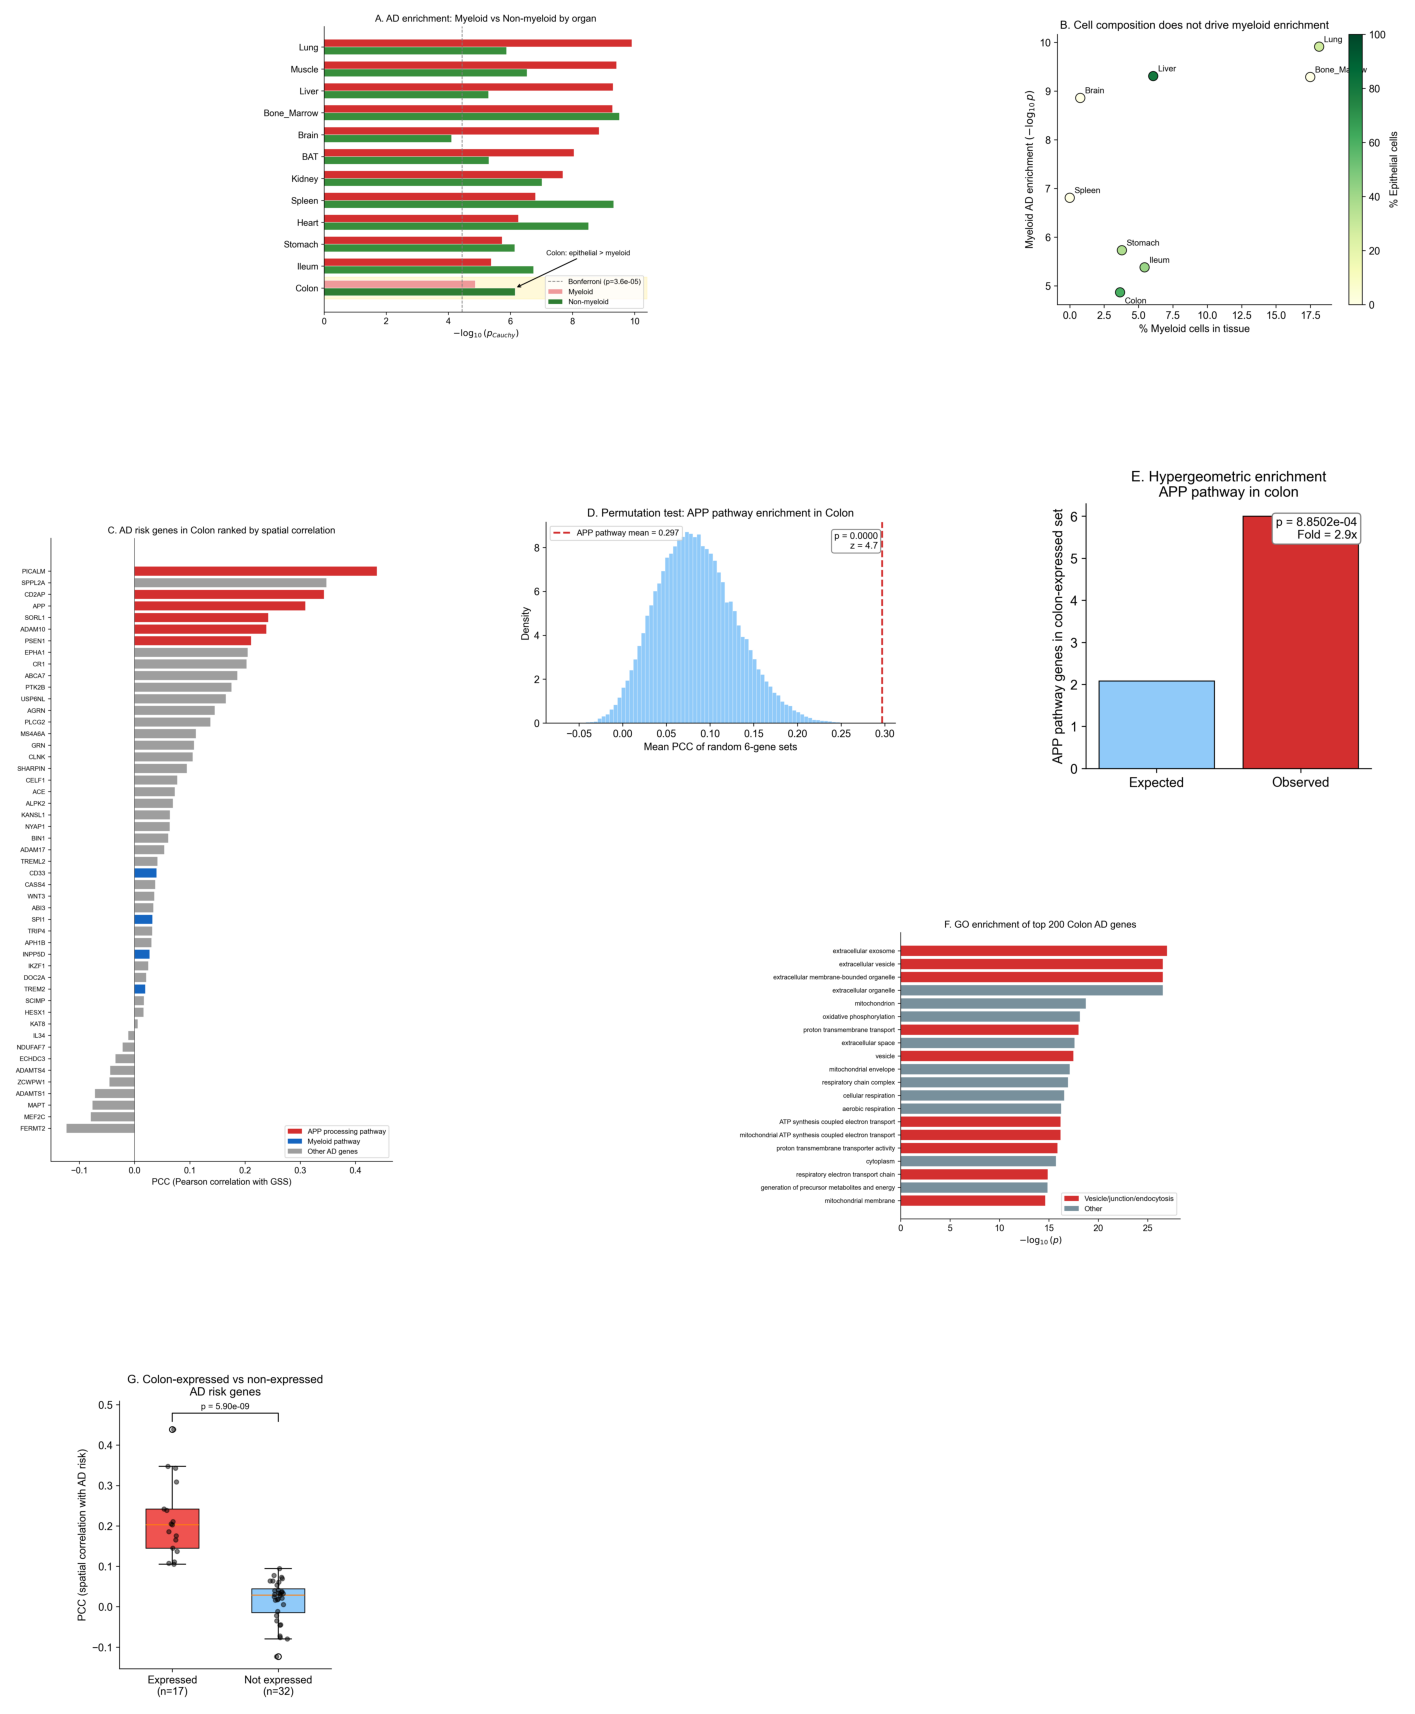

In [10]:
# Cell 11: Composite figure — combine panels A-G
from matplotlib.gridspec import GridSpec
from matplotlib.image import imread

fig = plt.figure(figsize=(18, 22))
gs = GridSpec(4, 3, figure=fig, hspace=0.35, wspace=0.3)

panel_files = {
    'A': f'{BASE}/figures/paper1/Fig2A_organ_myeloid_bars.png',
    'B': f'{BASE}/figures/paper1/Fig2B_composition_control.png',
    'C': f'{BASE}/figures/paper1/Fig2C_ad_genes_pcc.png',
    'D': f'{BASE}/figures/paper1/Fig2D_permutation_test.png',
    'E': f'{BASE}/figures/paper1/Fig2E_hypergeometric.png',
    'F': f'{BASE}/figures/paper1/Fig2F_go_enrichment.png',
    'G': f'{BASE}/figures/paper1/Fig2G_expressed_vs_not.png',
}

# Layout: Row 0: A (wide), B
#          Row 1: C (tall, spans 2 rows), D, E
#          Row 2: (C continues), F, G
#          Row 3: (empty or notes)

positions = {
    'A': gs[0, 0:2],
    'B': gs[0, 2],
    'C': gs[1:3, 0],
    'D': gs[1, 1],
    'E': gs[1, 2],
    'F': gs[2, 1:3],
    'G': gs[3, 0],
}

for label, pos in positions.items():
    ax = fig.add_subplot(pos)
    img_path = panel_files[label]
    if os.path.exists(img_path):
        img = imread(img_path)
        ax.imshow(img)
    ax.axis('off')

fig.savefig(f'{BASE}/figures/paper1/Fig2_colon_exception.png', dpi=300, bbox_inches='tight')
fig.savefig(f'{BASE}/figures/paper1/Fig2_colon_exception.pdf', bbox_inches='tight')
print('Composite figure saved to figures/paper1/Fig2_colon_exception.png and .pdf')
plt.show()
